<a href="https://colab.research.google.com/github/khushi-narang/ml/blob/main/Decision_Trees_and_Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load a classification dataset(Eg. Iris Dataset)

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# load iris dataset from scikit-learn
iris = load_iris()
x = iris.data
y = iris.target

# Convert the NumPy arrays to Pandas DataFrames for using .head()
x_df = pd.DataFrame(x, columns=iris.feature_names)  # Use feature names for columns
y_df = pd.DataFrame(y, columns=['target'])

print(x_df.shape)
print(x_df.head())  # Use .head() on the DataFrame
print(y_df.shape)
print(y_df.head())  # Use .head() on the DataFrame

(150, 4)
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2
(150, 1)
   target
0       0
1       0
2       0
3       0
4       0


Implement decision tree and random forest classifiers using scikit-learn.

In [ ]:
x_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


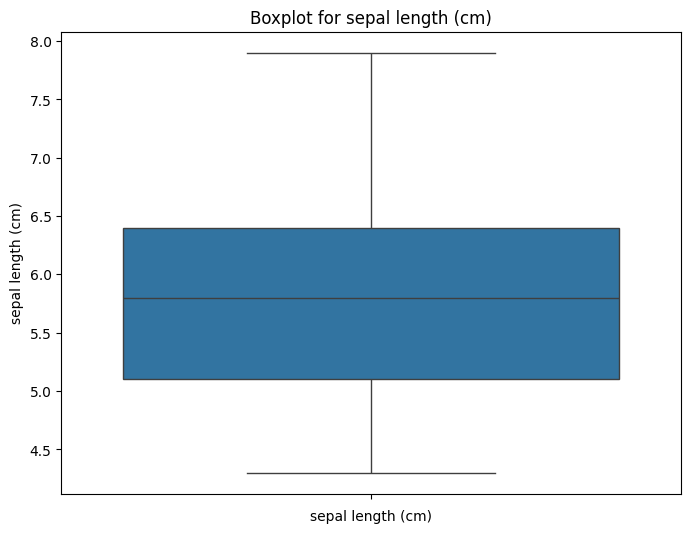

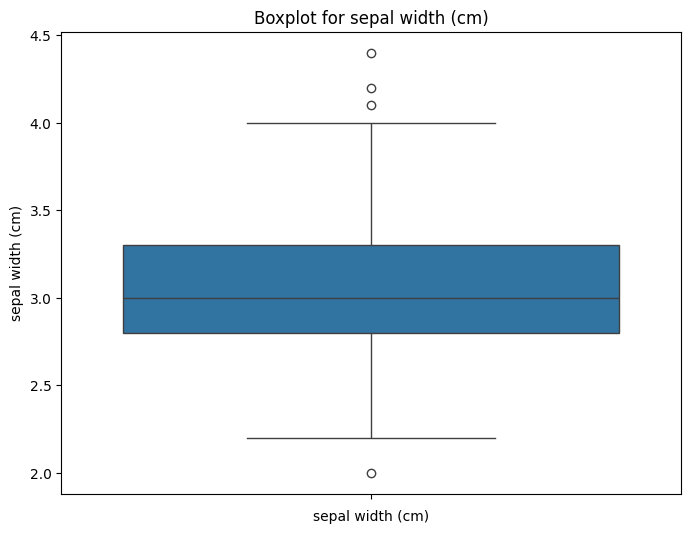

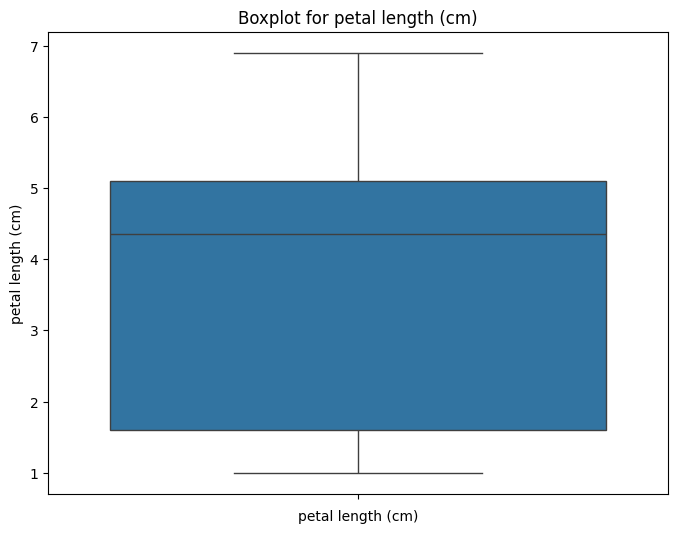

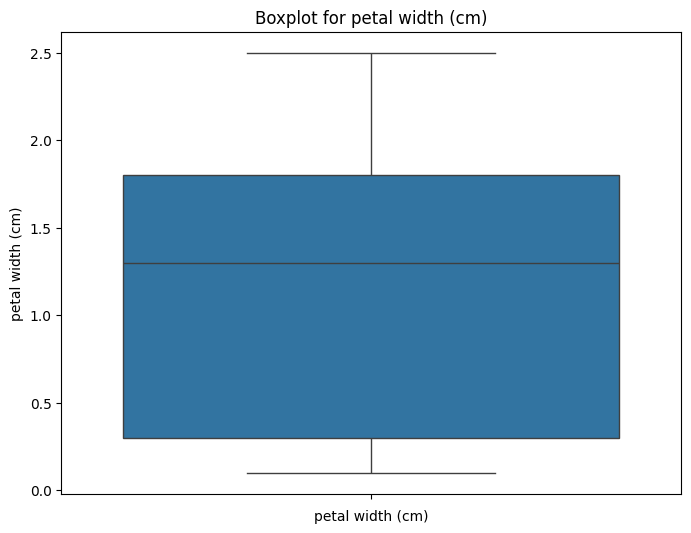

In [ ]:
for feature in x_df.columns:
  plt.figure(figsize=(8, 6))  # Adjust figure size if needed
  sns.boxplot(x_df[feature])  # Create the boxplot for outlier detection
  plt.title(f'Boxplot for {feature}')
  plt.xlabel(feature)
  plt.show()

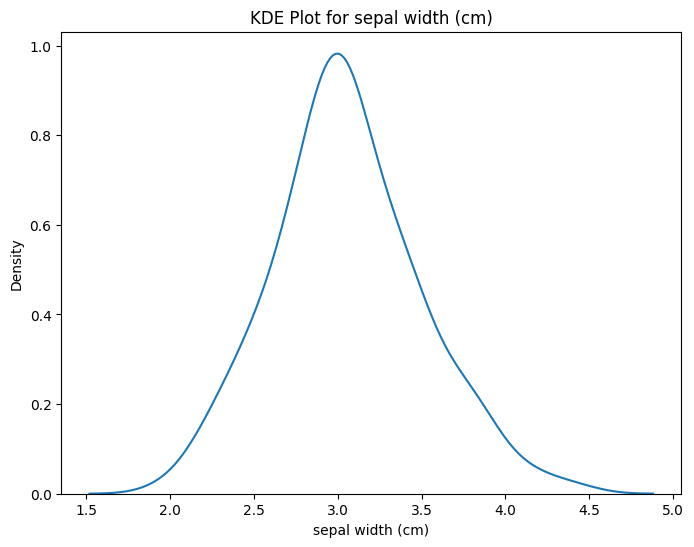

In [ ]:

feature = x_df['sepal width (cm)']
plt.figure(figsize=(8, 6))
sns.kdeplot(x_df['sepal width (cm)'])
plt.title("KDE Plot for sepal width (cm)")
plt.xlabel("sepal width (cm)")
plt.show()

In [ ]:
# Z-score outlier removal for 'sepal width (cm)'
from scipy import stats

z = np.abs(stats.zscore(x_df['sepal width (cm)']))
threshold = 3
x_df_filtered = x_df[(z < threshold)]
print(f"Shape of DataFrame before outlier removal: {x_df.shape}")
print(f"Shape of DataFrame after outlier removal: {x_df_filtered.shape}")


Shape of DataFrame before outlier removal: (150, 4)
Shape of DataFrame after outlier removal: (149, 4)


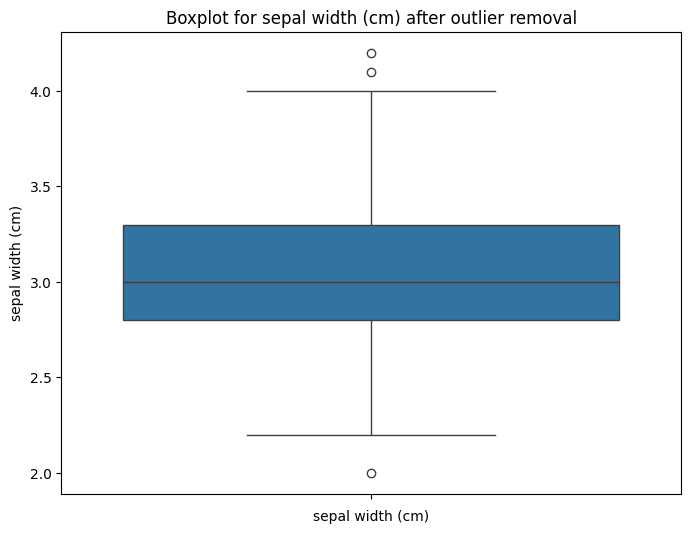

In [ ]:
# Create a boxplot after outlier removal for 'sepal width (cm)'
plt.figure(figsize=(8, 6))
sns.boxplot(x_df_filtered['sepal width (cm)'])
plt.title('Boxplot for sepal width (cm) after outlier removal')
plt.xlabel('sepal width (cm)')
plt.show()

In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=702)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score


decision_tree = DecisionTreeClassifier(random_state=72, max_depth = 5)
decision_tree.fit(X_train, y_train)
y_pred_dt = decision_tree.predict(X_test)


Evaluate the models, visualize the decision trees, and analyze feature importance

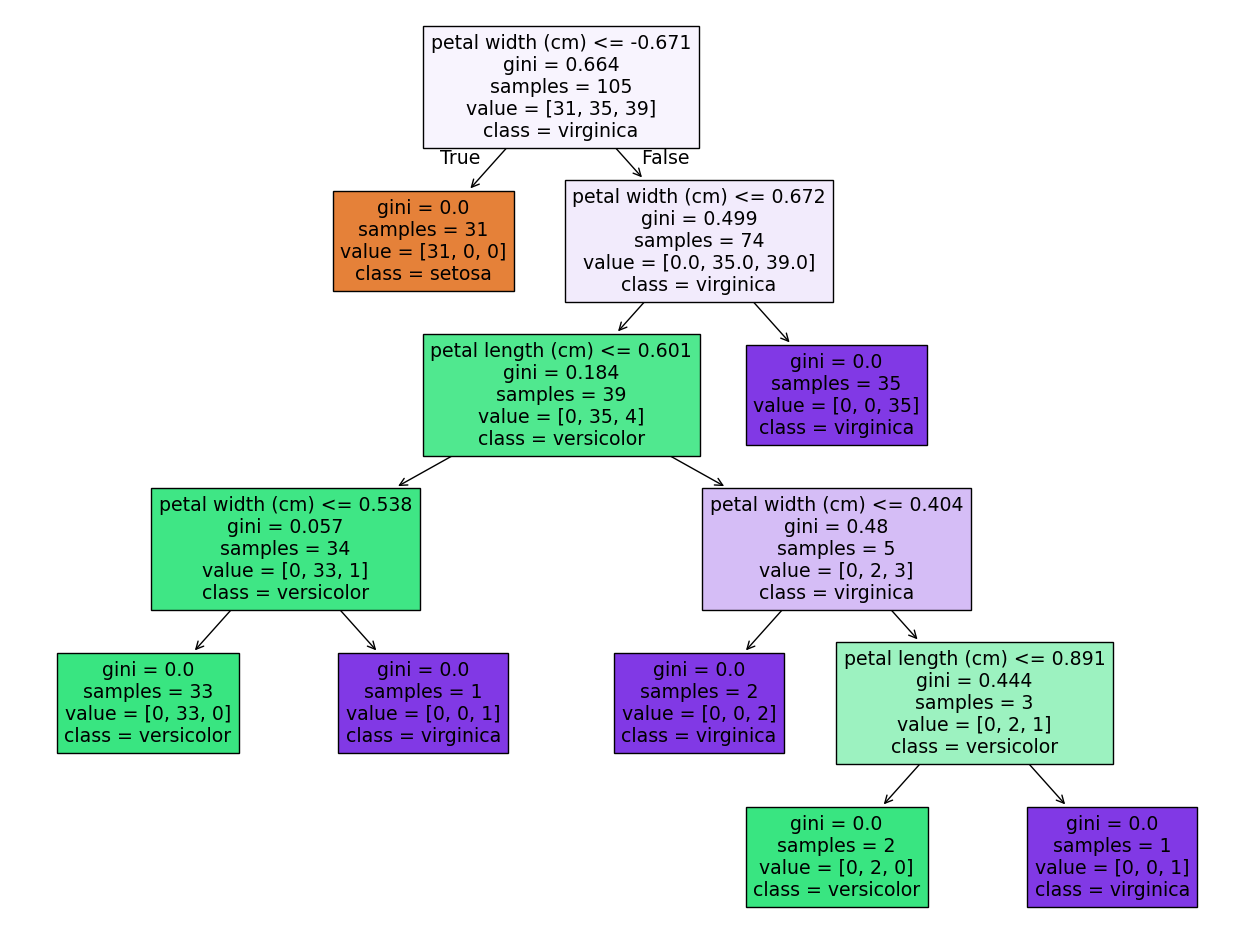

Random Forest Accuracy: 0.9777777777777777


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

# Visualize the Decision Tree
plt.figure(figsize=(16, 12))
plot_tree(decision_tree, feature_names=iris.feature_names, class_names=iris.target_names, filled=True, )
plt.show()

# Train a Random Forest Classifier (optional, for comparison)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)
y_pred_rf = random_forest.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)


In [ ]:
from sklearn.svm import SVC

kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
  svm_classifier = SVC(kernel=kernel, random_state=702)
  svm_classifier.fit(X_train, y_train)
  y_pred_svm = svm_classifier.predict(X_test)

  accuracy_svm = accuracy_score(y_test, y_pred_svm)
  print(f"SVM Accuracy with {kernel} kernel:", accuracy_svm)




SVM Accuracy with linear kernel: 0.9555555555555556
SVM Accuracy with poly kernel: 0.9333333333333333
SVM Accuracy with rbf kernel: 0.9777777777777777
SVM Accuracy with sigmoid kernel: 0.9333333333333333


In [ ]:
# prompt: analyse svm with test and train data and other matrix

from sklearn.metrics import classification_report, confusion_matrix

# ... (Your existing code for loading data, splitting, scaling, etc.) ...


# Iterate through different SVM kernels and analyze performance
kernels = ['linear', 'poly', 'rbf', 'sigmoid']

for kernel in kernels:
  svm_classifier = SVC(kernel=kernel, random_state=702)
  svm_classifier.fit(X_train, y_train)
  y_pred_svm = svm_classifier.predict(X_test)

  accuracy_svm = accuracy_score(y_test, y_pred_svm)
  print(f"\nSVM with {kernel} kernel:")
  print(f"Accuracy: {accuracy_svm}")

  # Generate and print the classification report
  print("Classification Report:")
  print(classification_report(y_test, y_pred_svm))

  # Generate and print the confusion matrix
  print("Confusion Matrix:")
  print(confusion_matrix(y_test, y_pred_svm))

  # Analyze feature importance (if applicable) -
  # Feature importance is more relevant to tree-based models
  # but can be attempted with SVM using techniques like permutation importance
  # result = permutation_importance(svm_classifier, X_test, y_test, n_repeats=10, random_state=42)
  # print("Feature Importances (Permutation Importance):")
  # for i in result.importances_mean.argsort()[::-1]:
  #   if result.importances_mean[i] - 2 * result.importances_std[i] > 0:
  #      print(f"  {iris.feature_names[i]}: {result.importances_mean[i]:.3f}")



SVM with linear kernel:
Accuracy: 0.9555555555555556
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.87      0.93        15
           2       0.85      1.00      0.92        11

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.95        45
weighted avg       0.96      0.96      0.96        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  2]
 [ 0  0 11]]

SVM with poly kernel:
Accuracy: 0.9333333333333333
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.83      1.00      0.91        15
           2       1.00      0.73      0.84        11

    accuracy                           0.93        45
   macro avg       0.94      0.91      0.92        45
weighted avg       0.94      0.93      0.93        45

Confusion Matrix:
[[19  0  0]
 